<h1 align="center"><font size="5">Project: Review analysis - Review analysis of Amazon Kindle Book Review</font></h1>

Dataset: all_kindle_review.csv

#### Data dictionary:

* asin - ID of the product, like B000FA64PK
* helpful - helpfulness rating of the review - example: 2/3.
* overall - rating of the product.
* reviewText - text of the review (heading).
* reviewTime - time of the review (raw).
* reviewerID - ID of the reviewer, like A3SPTOKDG7WBLN
* reviewerName - name of the reviewer.
* summary - summary of the review (description).
* unixReviewTime - unix timestamp.

## Set-up

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = '/content/drive/MyDrive/P4AIDS-Assignment/Text/input_data/all_kindle_review.csv'

## Import library

In [ ]:
!pip install langdetect
!pip install wordcloud
!pip install textblob
!pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import string
from tqdm import tqdm
import seaborn as sns
from wordcloud import WordCloud
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from textblob import Word
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.metrics.pairwise import cosine_similarity
from langdetect import detect

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from collections import Counter
from nltk.corpus import stopwords

## Read and overview dataset

In [ ]:
data = pd.read_csv(DATA_PATH)
data.head(5)

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [ ]:
data = data.loc[:, ~data.columns.str.contains("^Unnamed")]
data.head(5)

,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   asin            12000 non-null  object
 1   helpful         12000 non-null  object
 2   rating          12000 non-null  int64 
 3   reviewText      12000 non-null  object
 4   reviewTime      12000 non-null  object
 5   reviewerID      12000 non-null  object
 6   reviewerName    11962 non-null  object
 7   summary         11998 non-null  object
 8   unixReviewTime  12000 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 843.9+ KB


In [ ]:
data.describe()

,rating,unixReviewTime
count,12000.000000,1.200000e+04
mean,3.250000,1.344537e+09
std,1.421619,4.369374e+07
min,1.000000,9.602496e+08
25%,2.000000,1.316218e+09
50%,3.500000,1.356826e+09
75%,4.250000,1.376870e+09
max,5.000000,1.405814e+09


In [ ]:
print("===== DATASET OVERVIEW =====")

num_samples = len(data)
num_categories = data['rating'].nunique()
missing = data.isnull().sum()

data['word_count'] = data['reviewText'].astype(str).apply(lambda x: len(x.split()))
data['char_count'] = data['reviewText'].astype(str).apply(len)

avg_words = data['word_count'].mean()
avg_chars = data['char_count'].mean()

print(f"Samples: {num_samples}")
print(f"Categories (rating): {num_categories}")
print(f"Avg words / review: {avg_words:.2f}")
print(f"Avg chars / review: {avg_chars:.2f}")

print("\n===== MISSING VALUES =====")
print(missing)

===== DATASET OVERVIEW =====
Samples: 12000
Categories (rating): 5
Avg words / review: 109.24
Avg chars / review: 601.56

===== MISSING VALUES =====
asin               0
helpful            0
rating             0
reviewText         0
reviewTime         0
reviewerID         0
reviewerName      38
summary            2
unixReviewTime     0
dtype: int64


In [ ]:
print(data.columns)

Index(['asin', 'helpful', 'rating', 'reviewText', 'reviewTime', 'reviewerID',
       'reviewerName', 'summary', 'unixReviewTime', 'word_count',
       'char_count'],
      dtype='object')


In [ ]:
# xem vài mẫu
for r, grp in data.groupby('rating'):
  print("="*25)
  print(f'sample for rating {r}:', grp['reviewText'].iloc[0])
  print("="*25)

sample for rating 1: I received a copy of book to review. "A secret society. A fanatical cult. A telepathic girl." are not my cup of tea. This was not what I expected and I really don't need another continuational book. I still haven't read the Catching Fire from the Hunger Games. I don't get into all this sci-fi stuff. Just not my cup of tea. Sorry.
sample for rating 2: This has the makings of a good story... unfortunately it disappoints.it tells of two alpha were who are members of unfriendly packs... they have grown up together with one being gay and the other straight... then when it seems they are about to get together something happens and the story is told in alternating chapters of past and present.. the story and the couple fall apart in the switch of time and lack of a sustainable reason for the break.
sample for rating 3: Jace Rankin may be short, but he's nothing to mess with, as the man who was just hauled out of the saloon by the undertaker knows now. He's a famous bounty

## Rating Distribution

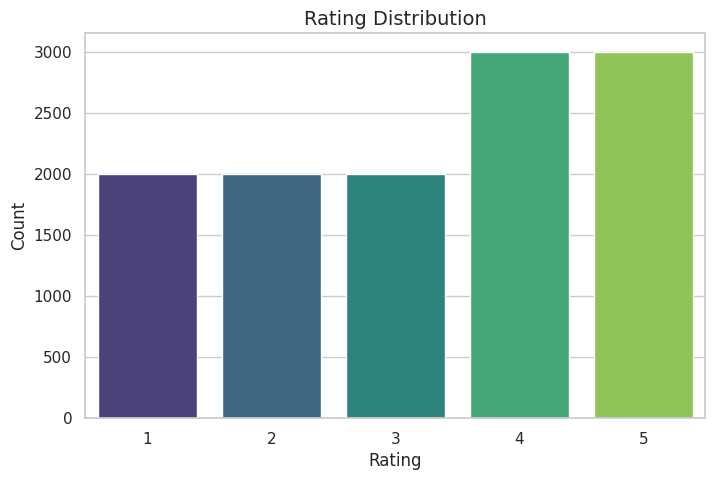

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=data, palette='viridis')
plt.title("Rating Distribution", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

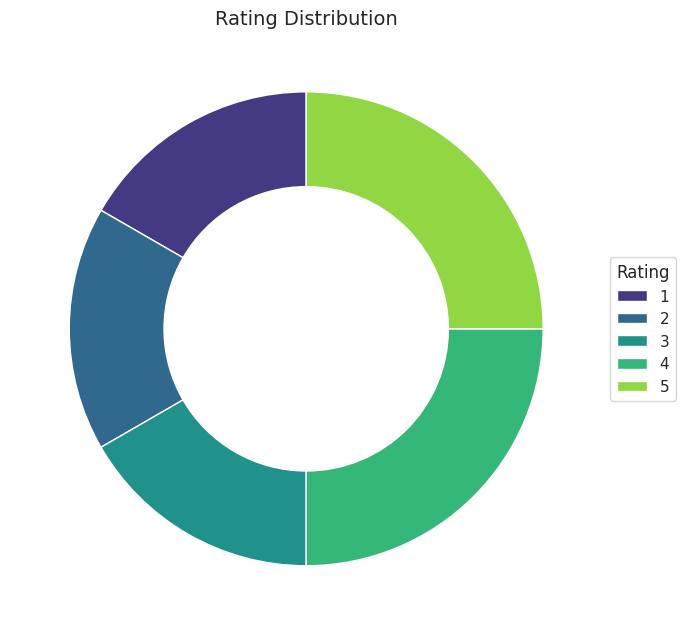

In [ ]:
rating_counts = data['rating'].value_counts().sort_index()
colors = sns.color_palette("viridis", len(rating_counts))

plt.figure(figsize=(7,7))

wedges, texts = plt.pie(
    rating_counts,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor='white')  # ace donut
)

plt.legend(
    wedges,
    rating_counts.index,
    title="Rating",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Rating Distribution", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
data.rating.value_counts()

,count
rating,
5,3000
4,3000
3,2000
2,2000
1,2000


Star >= 3 would be positive, others must be negative

In [ ]:
data['sentiment'] = data['rating'].apply(lambda x: 1 if x>=3 else 0)

In [ ]:
data.head()

,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime,word_count,char_count,sentiment
0,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600,541,2921,1
1,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400,69,371,1
2,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400,76,416,1
3,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400,54,336,1
4,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000,20,90,1


In [ ]:
data.sentiment.value_counts()

,count
sentiment,
1,8000
0,4000


Seem that we have imbalance dataset problem, need to handle in later step

In [ ]:
# if 'word_count' not in data.columns:
#     data['word_count'] = data['reviewText'].astype(str).apply(lambda x: len(x.split()))

stats = data.groupby('rating').agg(
    Count=('rating', 'count'),
    Avg_Words=('word_count', 'mean')
).reset_index()

stats.columns = ['Category', 'Count', 'Avg Words']
stats['Percentage'] = stats['Count'] / stats['Count'].sum() * 100

stats['Percentage'] = stats['Percentage'].map(lambda x: f"{x:.1f}%")
stats['Avg Words'] = stats['Avg Words'].map(lambda x: f"{x:.1f}")

stats = stats[['Category', 'Count', 'Percentage', 'Avg Words']]

stats.style \
    .background_gradient(cmap='Blues', subset=['Count']) \
    .background_gradient(cmap='YlGn', subset=['Avg Words']) \
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12pt'
    }) \
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('font-size', '13pt'),
                ('text-align', 'center'),
                ('background-color', '#40466e'),
                ('color', 'white')
            ]
        }
    ]) \
    .set_caption("Dataset Statistics by Rating")

,Category,Count,Percentage,Avg Words
0,1,2000,16.7%,96.1
1,2,2000,16.7%,115.2
2,3,2000,16.7%,119.3
3,4,3000,25.0%,119.4
4,5,3000,25.0%,97.1


## Stopword analysis

In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

all_words = " ".join(data['reviewText'].astype(str)).lower().split()
stopword_list = [word for word in all_words if word in stop_words]
stopword_counts = Counter(stopword_list)

top10 = stopword_counts.most_common(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


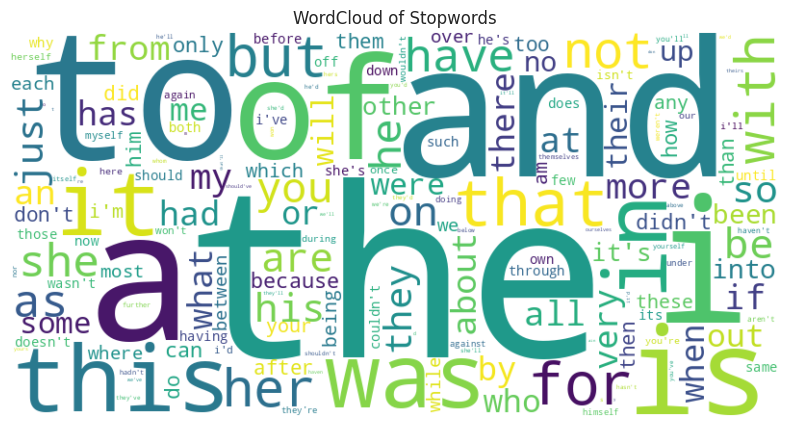

In [ ]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(stopword_counts)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Stopwords')
plt.show()

In [ ]:
total_words = len(all_words)
total_stopwords = len(stopword_list)

percent_stopwords = (total_stopwords / total_words) * 100

print(f"Total words: {total_words}")
print(f"Total stopwords: {total_stopwords}")
print(f"Percentage of stopwords: {percent_stopwords:.2f}%")

Total words: 1310842
Total stopwords: 644325
Percentage of stopwords: 49.15%


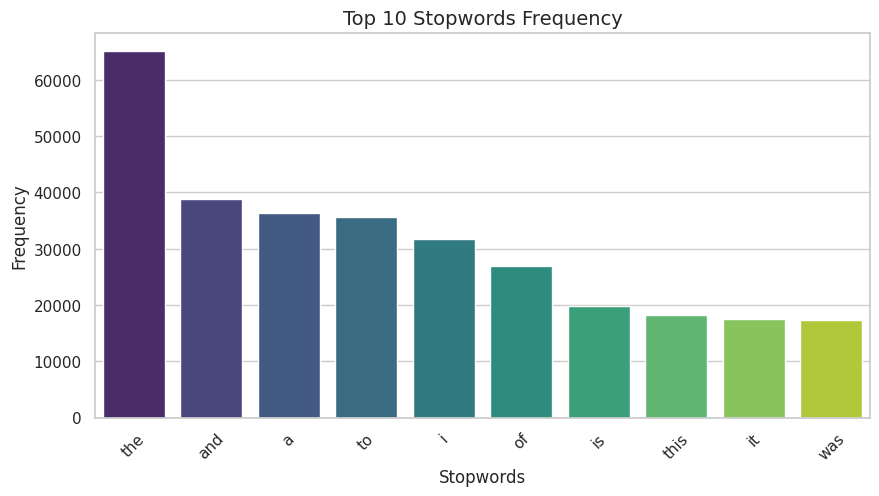

In [ ]:
words = [w for w, _ in top10]
counts = [c for _, c in top10]

sns.set(style="whitegrid")

plt.figure(figsize=(10,5))
sns.barplot(x=words, y=counts, palette='viridis')

plt.title("Top 10 Stopwords Frequency", fontsize=14)
plt.xlabel("Stopwords")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.show()

In [ ]:
top30 = stopword_counts.most_common(50)

for i, (word, _) in enumerate(top30, 1):
    print(word, end=', ')
    if i % 10 == 0:
        print()

the, and, a, to, i, of, is, this, it, was, 
in, that, for, but, with, her, not, have, as, she, 
he, you, be, on, are, his, just, so, they, at, 
my, more, all, an, from, about, if, what, had, there, 
has, very, by, when, or, out, me, who, were, some, 


## Word & Char Count Distribution

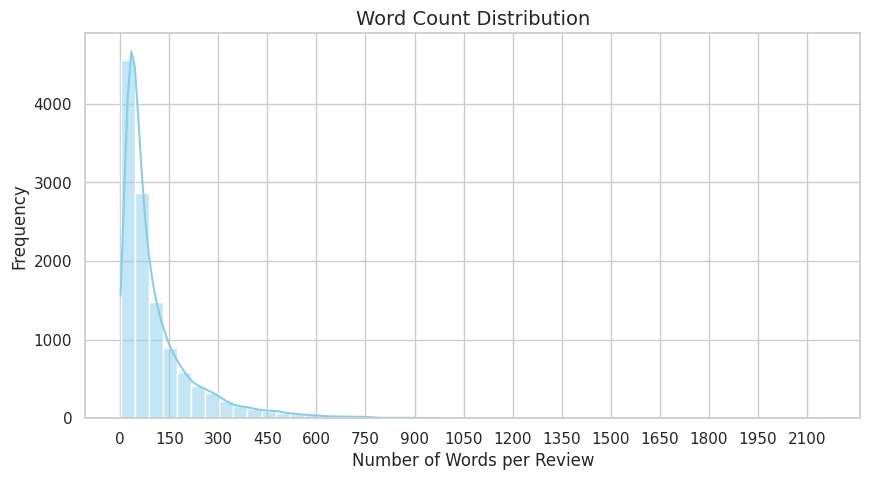

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(10,5))

sns.histplot(
    data['word_count'],
    bins=50,
    kde=True,
    color='skyblue'
)

max_val = data['word_count'].max()
plt.xticks(np.arange(0, max_val, 150))

plt.title("Word Count Distribution", fontsize=14)
plt.xlabel("Number of Words per Review")
plt.ylabel("Frequency")

plt.show()

## Pre-processing data for further analysis

#### Convert to lower case

In [ ]:
data_cleaned = data.copy()

In [ ]:
data_cleaned.reviewText = data_cleaned['reviewText'].apply(lambda x: x.lower())
data_cleaned.reviewText.head()

,reviewText
0,"jace rankin may be short, but he's nothing to ..."
1,great short read. i didn't want to put it dow...
2,i'll start by saying this is the first of four...
3,aggie is angela lansbury who carries pocketboo...
4,i did not expect this type of book to be in li...


#### Check duplicate and remove

In [ ]:
data_cleaned.reviewText.duplicated().sum()

np.int64(0)

No duplicated data

#### Check missing values

In [ ]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   asin            12000 non-null  object
 1   helpful         12000 non-null  object
 2   rating          12000 non-null  int64 
 3   reviewText      12000 non-null  object
 4   reviewTime      12000 non-null  object
 5   reviewerID      12000 non-null  object
 6   reviewerName    11962 non-null  object
 7   summary         11998 non-null  object
 8   unixReviewTime  12000 non-null  int64 
 9   word_count      12000 non-null  int64 
 10  char_count      12000 non-null  int64 
 11  sentiment       12000 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 1.1+ MB


Missing values here is not considered

#### Check Language of review

In [ ]:
tqdm.pandas()
df_check_lang = data_cleaned['reviewText'].progress_apply(detect)

100%|██████████| 12000/12000 [00:47<00:00, 253.69it/s]


In [ ]:
df_check_lang.value_counts()

,count
reviewText,
en,11992
af,4
cs,1
sl,1
no,1
es,1


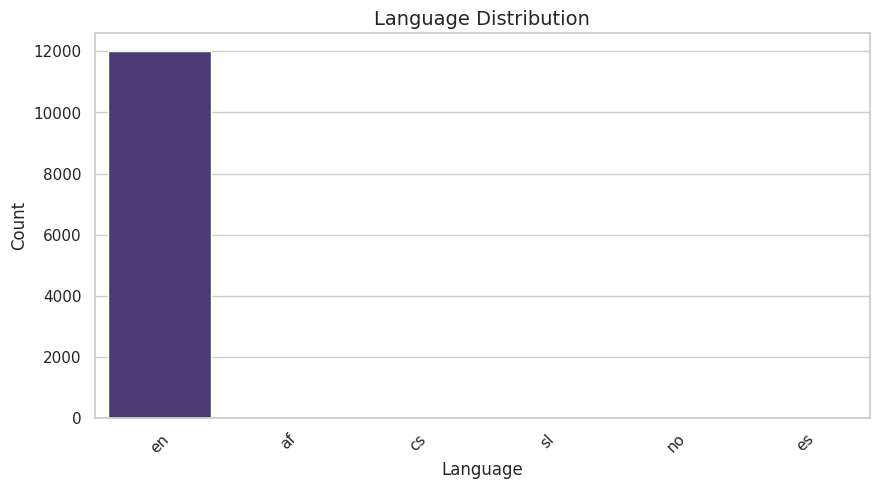

In [ ]:
sns.set(style="whitegrid")
lang_counts = df_check_lang.value_counts()

plt.figure(figsize=(10,5))

sns.barplot(
    x=lang_counts.index,
    y=lang_counts.values,
    palette='viridis'
)

plt.title("Language Distribution", fontsize=14)
plt.xlabel("Language")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

* Most of language is english, need to remove others

In [ ]:
data_cleaned = data_cleaned[df_check_lang=='en']

#### Removing Punctuation

In [ ]:
data_cleaned.reviewText = data_cleaned['reviewText'].apply(lambda x: ''.join(char for char in x if char not in string.punctuation))
data_cleaned.reviewText.head()

,reviewText
0,jace rankin may be short but hes nothing to me...
1,great short read i didnt want to put it down ...
2,ill start by saying this is the first of four ...
3,aggie is angela lansbury who carries pocketboo...
4,i did not expect this type of book to be in li...


#### Replace Numbers with a Space

In [ ]:
data_cleaned.reviewText = data_cleaned.reviewText.str.replace('\d+', ' ', regex=True)
data_cleaned.reviewText = data_cleaned.reviewText.str.replace('\s+', ' ', regex=True)
data_cleaned.reviewText.head()

,reviewText
0,jace rankin may be short but hes nothing to me...
1,great short read i didnt want to put it down s...
2,ill start by saying this is the first of four ...
3,aggie is angela lansbury who carries pocketboo...
4,i did not expect this type of book to be in li...


#### Remove stopword

In [ ]:
stop_words = set(stopwords.words('english'))

data_cleaned['reviewText'] = data_cleaned['reviewText'].apply(
    lambda x: ' '.join(word for word in x.split() if word not in stop_words)
)

In [ ]:
data_cleaned.reviewText.head()

,reviewText
0,jace rankin may short hes nothing mess man hau...
1,great short read didnt want put read one sitti...
2,ill start saying first four books wasnt expect...
3,aggie angela lansbury carries pocketbooks inst...
4,expect type book library pleased find price right


#### Lemmatization

In [ ]:
nltk.download('wordnet')
lemma = WordNetLemmatizer()
data.reviewText = data.reviewText.apply(lambda x: ' '.join(lemma.lemmatize(word) for word in x.split()))
data.reviewText.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,reviewText
0,"Jace Rankin may be short, but he's nothing to ..."
1,Great short read. I didn't want to put it down...
2,I'll start by saying this is the first of four...
3,Aggie is Angela Lansbury who carry pocketbook ...
4,I did not expect this type of book to be in li...


In [ ]:
data_cleaned['tokens'] = data_cleaned['reviewText'].apply(lambda x: x.split())

## Vocabulary and Meaningful Words

In [ ]:
stats = []

for rating, group in data_cleaned.groupby('rating'):
    all_words = [w for tokens in group['tokens'] for w in tokens]

    total_words = len(all_words)
    unique_words = len(set(all_words))
    reviews = len(group)

    stats.append([rating, total_words, unique_words, reviews])

vocab_df = pd.DataFrame(stats, columns=[
    'Rating', 'Total Words', 'Unique Words', 'Reviews'
]).sort_values('Rating')

vocab_df.style \
    .background_gradient(cmap='Blues', subset=['Total Words']) \
    .background_gradient(cmap='Greens', subset=['Unique Words']) \
    .background_gradient(cmap='Oranges', subset=['Reviews']) \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#40466e'),
                   ('color', 'white'),
                   ('text-align', 'center')]}
    ]) \
    .set_caption("Vocabulary Statistics by Rating")

,Rating,Total Words,Unique Words,Reviews
0,1,93889,13708,1999
1,2,112807,15468,1998
2,3,117342,15986,2000
3,4,179323,21003,2997
4,5,146496,18258,2998


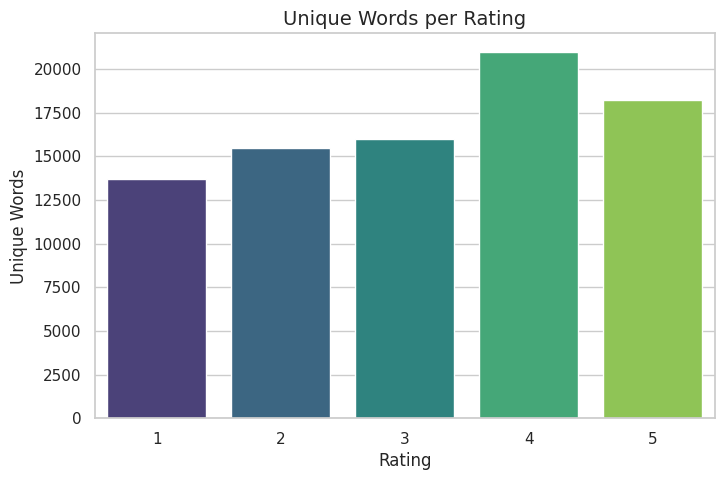

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Rating',
    y='Unique Words',
    data=vocab_df,
    palette='viridis'
)

plt.title("Unique Words per Rating", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Unique Words")

plt.show()

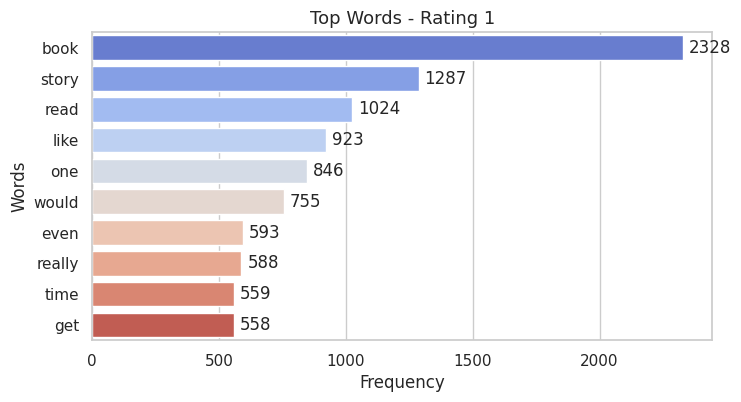

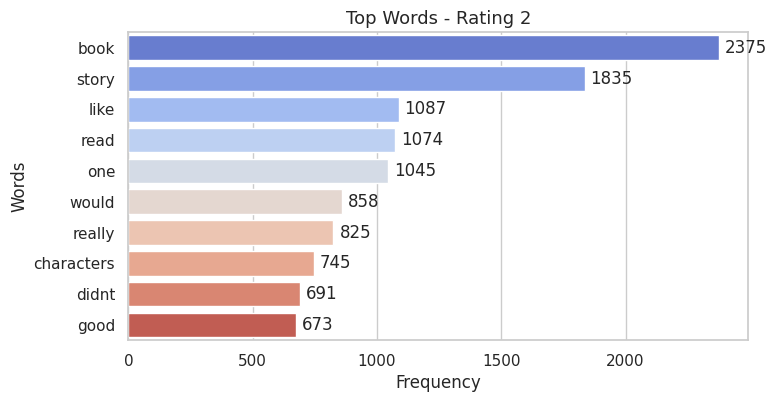

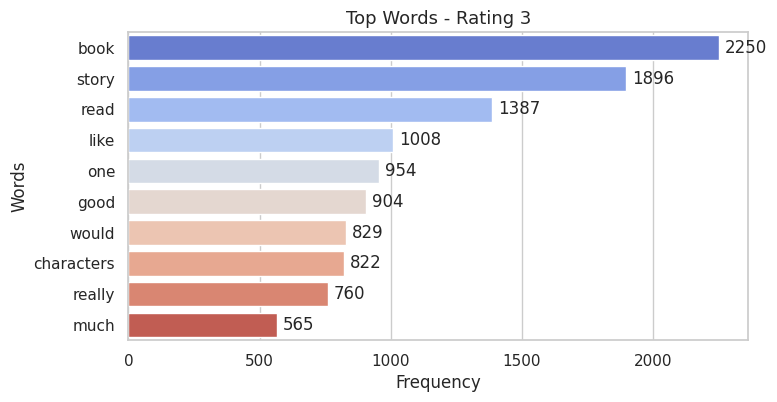

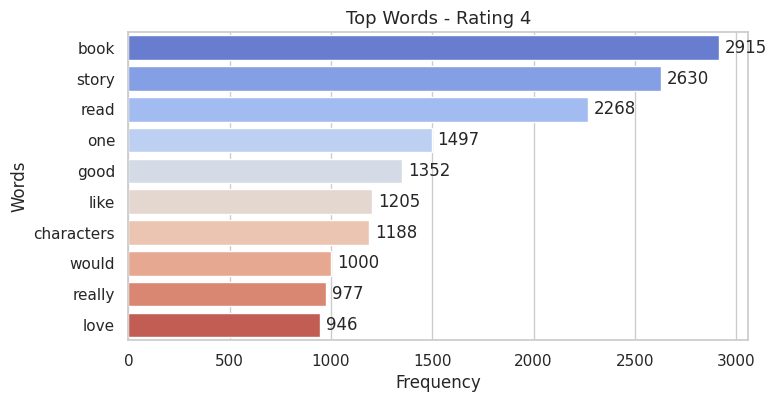

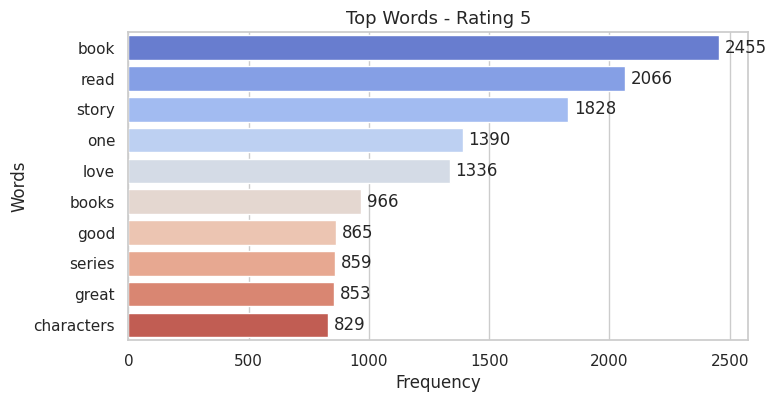

In [ ]:
for rating, group in data_cleaned.groupby('rating'):

    all_words = [w for tokens in group['tokens'] for w in tokens]
    counter = Counter(all_words)
    top10 = counter.most_common(10)

    words = [w for w, _ in top10]
    counts = [c for _, c in top10]

    plt.figure(figsize=(8,4))

    ax = sns.barplot(
        x=counts,
        y=words,
        palette='coolwarm'
    )

    for i, v in enumerate(counts):
        ax.text(v + max(counts)*0.01, i, str(v), va='center')

    plt.title(f"Top Words - Rating {rating}", fontsize=13)
    plt.xlabel("Frequency")
    plt.ylabel("Words")

    plt.show()

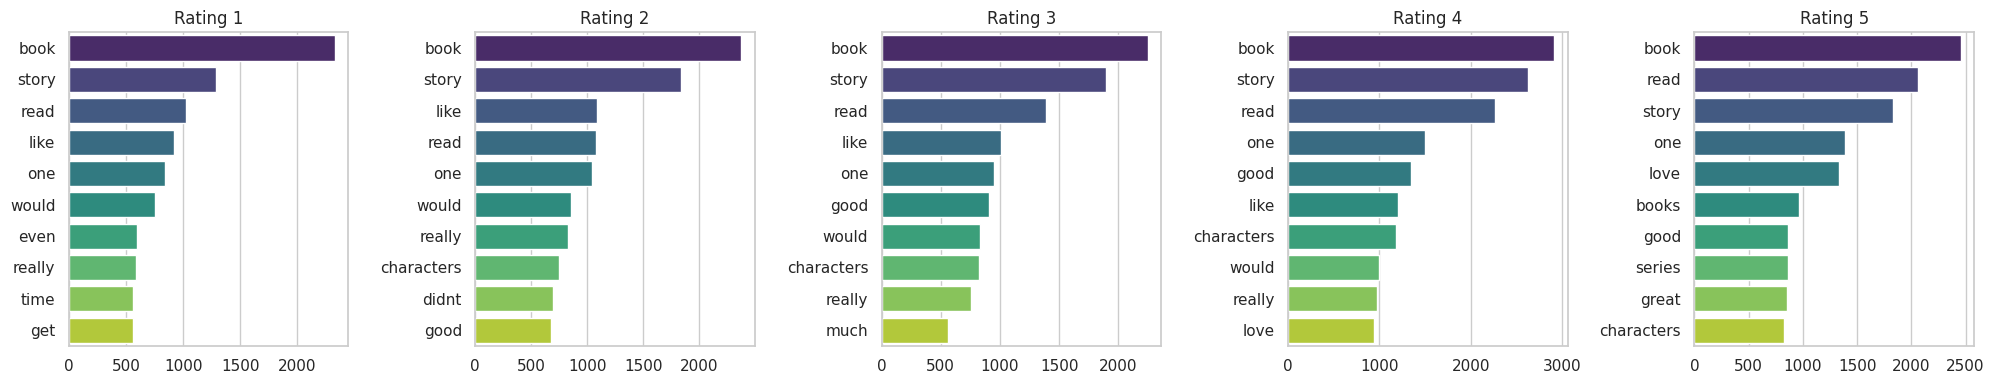

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20,4))

for idx, (rating, group) in enumerate(data_cleaned.groupby('rating')):

    all_words = [w for tokens in group['tokens'] for w in tokens]
    counter = Counter(all_words)
    top10 = counter.most_common(10)

    words = [w for w, _ in top10]
    counts = [c for _, c in top10]

    sns.barplot(
        x=counts,
        y=words,
        ax=axes[idx],
        palette='viridis'
    )

    axes[idx].set_title(f"Rating {rating}")
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("")

plt.tight_layout()
plt.show()

## Distinctive words on each rating

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data_cleaned['reviewText'])

feature_names = tfidf.get_feature_names_out()

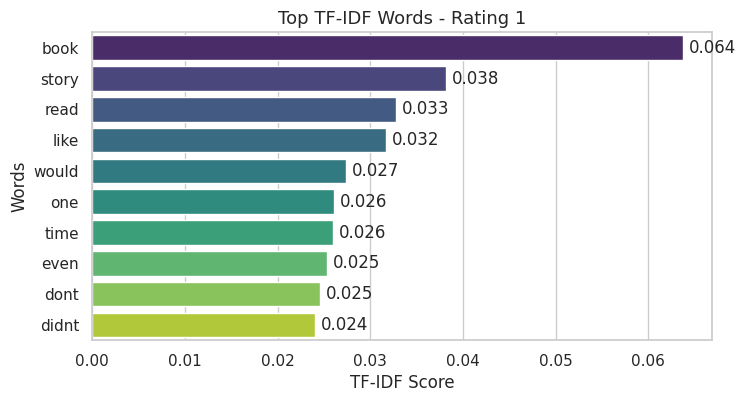

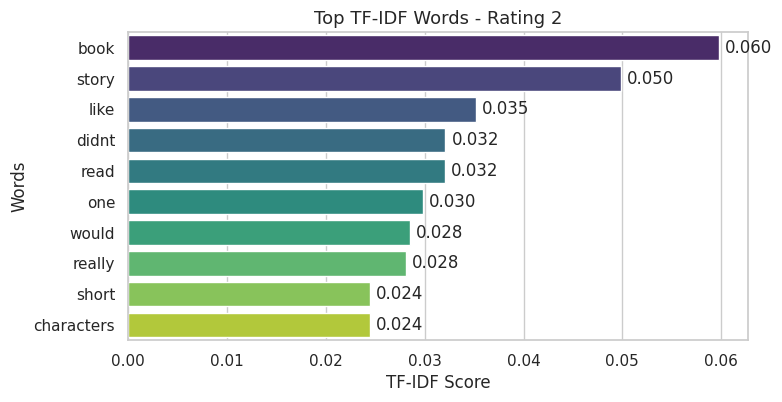

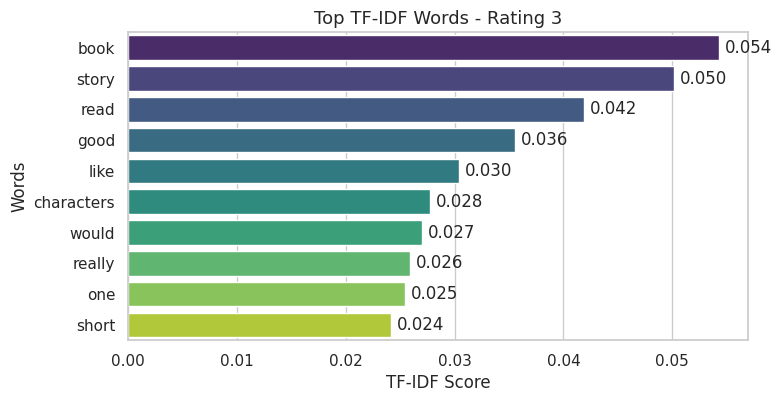

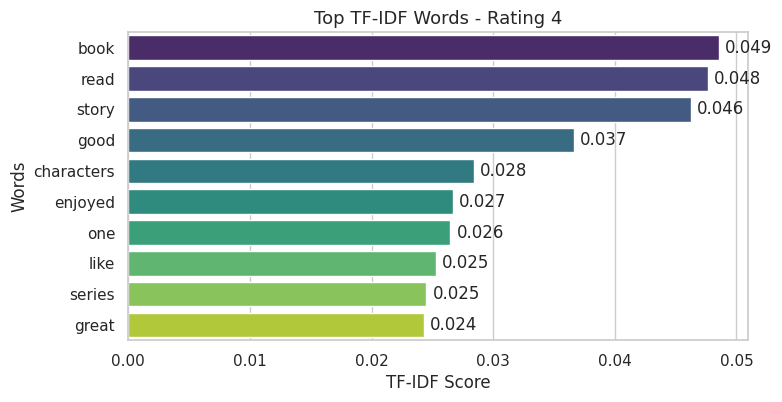

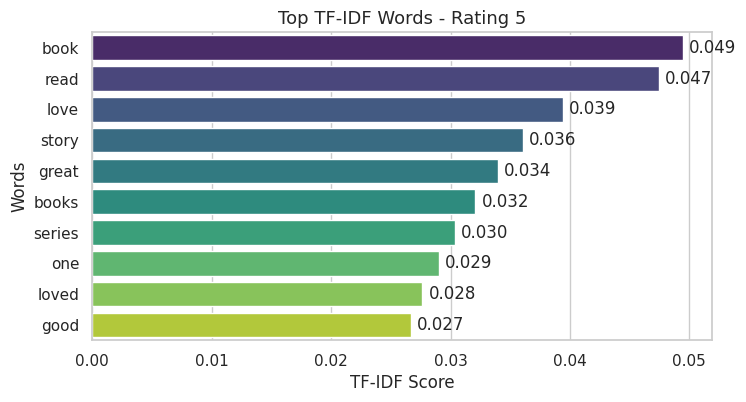

In [ ]:
ratings = sorted(data_cleaned['rating'].unique())

for rating in ratings:

    # lấy index của rating đó
    idx = (data_cleaned['rating'] == rating).values

    # lấy TF-IDF của group
    X_group = X[idx]

    # tính mean score mỗi word
    mean_tfidf = np.asarray(X_group.mean(axis=0)).ravel()

    # lấy top 10
    top_idx = mean_tfidf.argsort()[-10:][::-1]

    top_words = [feature_names[i] for i in top_idx]
    top_scores = mean_tfidf[top_idx]

    # plot
    plt.figure(figsize=(8,4))

    ax = sns.barplot(
        x=top_scores,
        y=top_words,
        palette='viridis'
    )

    # label số
    for i, v in enumerate(top_scores):
        ax.text(v + max(top_scores)*0.01, i, f"{v:.3f}", va='center')

    plt.title(f"Top TF-IDF Words - Rating {rating}", fontsize=13)
    plt.xlabel("TF-IDF Score")
    plt.ylabel("Words")

    plt.show()

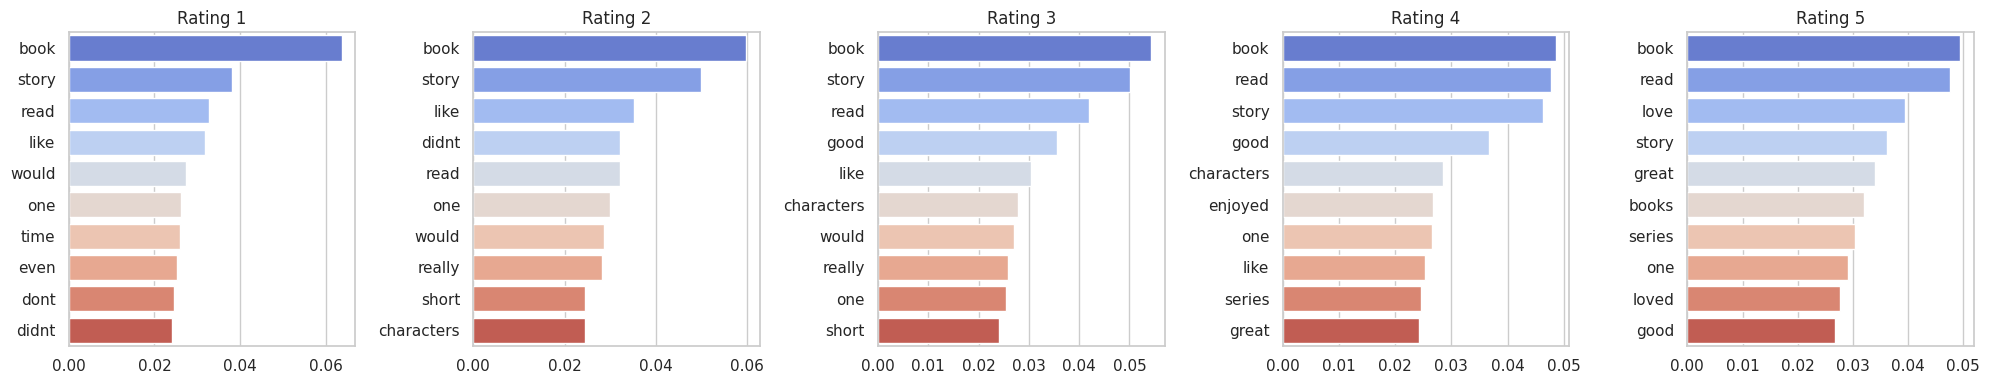

In [ ]:
fig, axes = plt.subplots(1, len(ratings), figsize=(20,4))

for idx_r, rating in enumerate(ratings):

    idx = (data_cleaned['rating'] == rating).values
    X_group = X[idx]

    mean_tfidf = np.asarray(X_group.mean(axis=0)).ravel()
    top_idx = mean_tfidf.argsort()[-10:][::-1]

    top_words = [feature_names[i] for i in top_idx]
    top_scores = mean_tfidf[top_idx]

    sns.barplot(
        x=top_scores,
        y=top_words,
        ax=axes[idx_r],
        palette='coolwarm'
    )

    axes[idx_r].set_title(f"Rating {rating}")
    axes[idx_r].set_xlabel("")
    axes[idx_r].set_ylabel("")

plt.tight_layout()
plt.show()

## N-gram Analysis

In [ ]:
tfidf_ngram = TfidfVectorizer(
    ngram_range=(2,2),   # bigram
    max_features=5000
)

X_ngram = tfidf_ngram.fit_transform(data_cleaned['reviewText'])
feature_names_ngram = tfidf_ngram.get_feature_names_out()

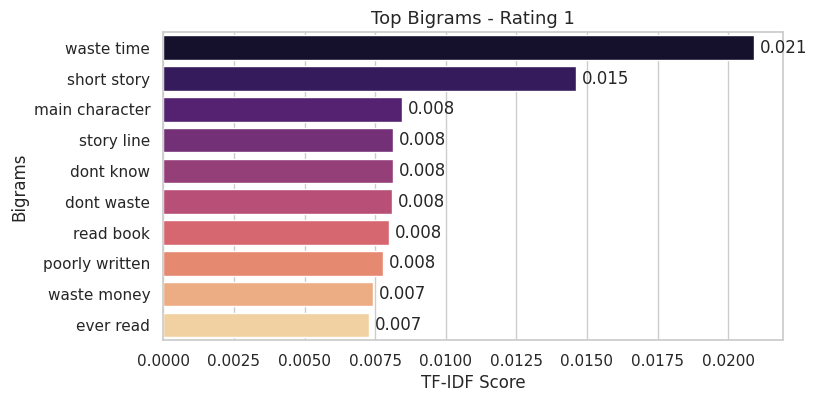

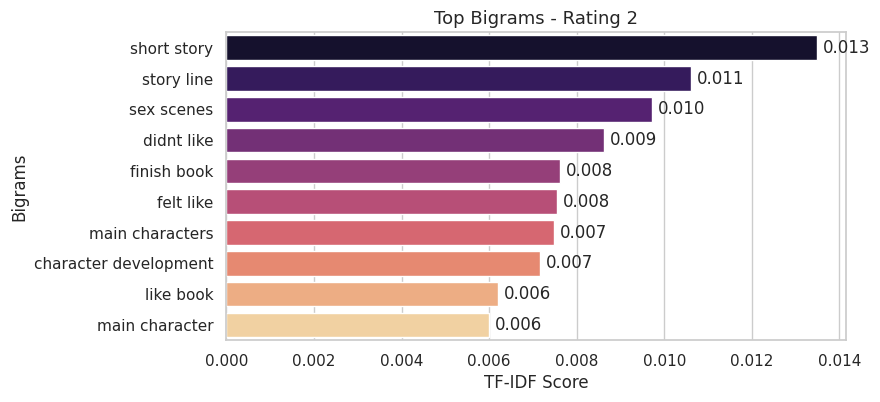

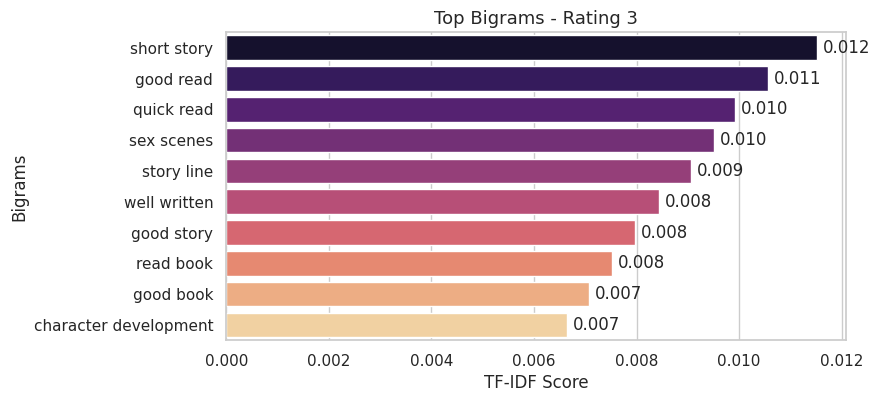

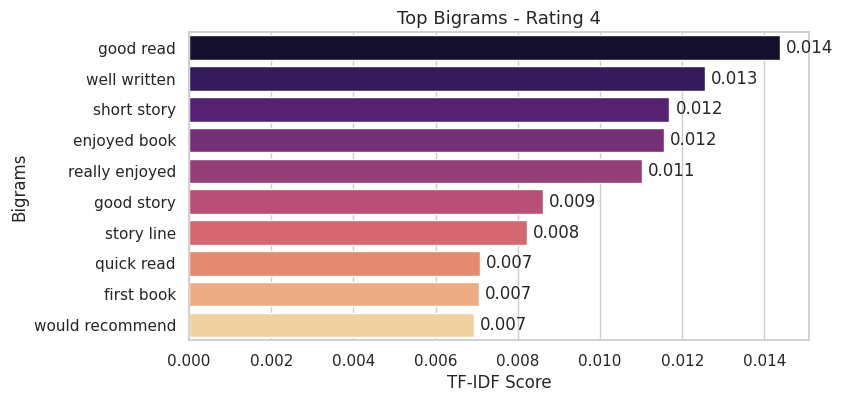

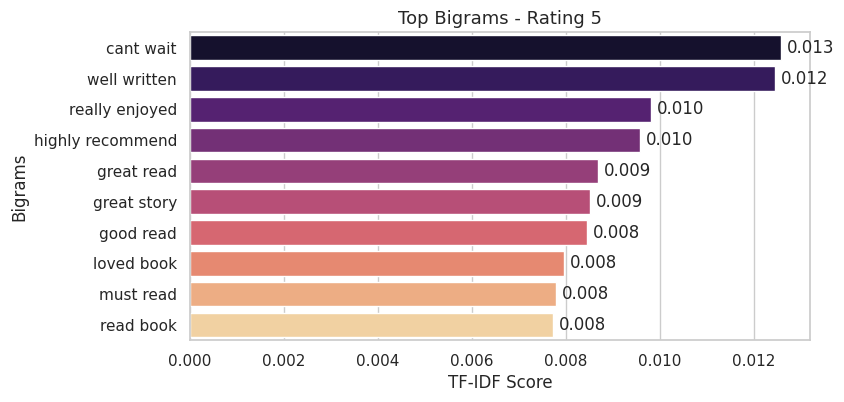

In [ ]:
ratings = sorted(data_cleaned['rating'].unique())

for rating in ratings:

    idx = (data_cleaned['rating'] == rating).values
    X_group = X_ngram[idx]

    mean_tfidf = np.asarray(X_group.mean(axis=0)).ravel()

    top_idx = mean_tfidf.argsort()[-10:][::-1]

    top_ngrams = [feature_names_ngram[i] for i in top_idx]
    top_scores = mean_tfidf[top_idx]

    plt.figure(figsize=(8,4))

    ax = sns.barplot(
        x=top_scores,
        y=top_ngrams,
        palette='magma'
    )

    for i, v in enumerate(top_scores):
        ax.text(v + max(top_scores)*0.01, i, f"{v:.3f}", va='center')

    plt.title(f"Top Bigrams - Rating {rating}", fontsize=13)
    plt.xlabel("TF-IDF Score")
    plt.ylabel("Bigrams")

    plt.show()

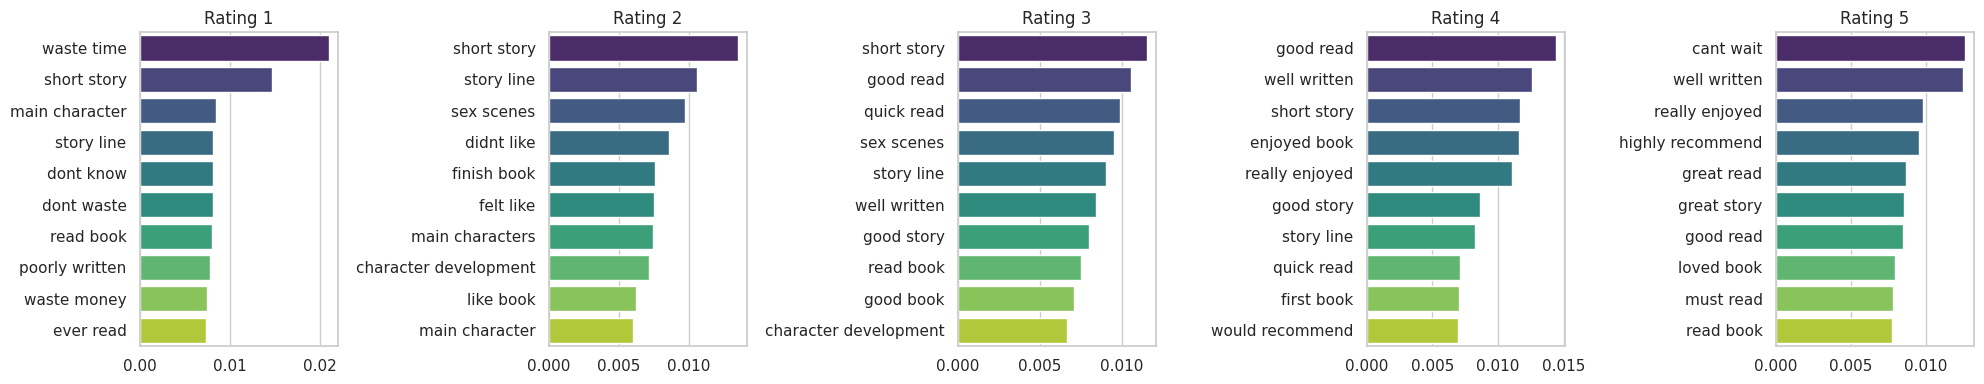

In [ ]:
fig, axes = plt.subplots(1, len(ratings), figsize=(20,4))

for idx_r, rating in enumerate(ratings):

    idx = (data_cleaned['rating'] == rating).values
    X_group = X_ngram[idx]

    mean_tfidf = np.asarray(X_group.mean(axis=0)).ravel()
    top_idx = mean_tfidf.argsort()[-10:][::-1]

    top_ngrams = [feature_names_ngram[i] for i in top_idx]
    top_scores = mean_tfidf[top_idx]

    sns.barplot(
        x=top_scores,
        y=top_ngrams,
        ax=axes[idx_r],
        palette='viridis'
    )

    axes[idx_r].set_title(f"Rating {rating}")
    axes[idx_r].set_xlabel("")
    axes[idx_r].set_ylabel("")

plt.tight_layout()
plt.show()

## Cosine Matrix

In [ ]:
ratings = sorted(data_cleaned['rating'].unique())

sim_matrix = np.zeros((len(ratings), len(ratings)))


for i, r1 in enumerate(ratings):

    idx1 = np.where(data_cleaned['rating'] == r1)[0]
    X1 = X[idx1]

    for j, r2 in enumerate(ratings):
        idx2 = np.where(data_cleaned['rating'] == r2)[0]
        X2 = X[idx2]

        # cosine toàn bộ cặp
        sim = cosine_similarity(X1, X2)

        # lấy trung bình
        sim_matrix[i, j] = sim.mean()

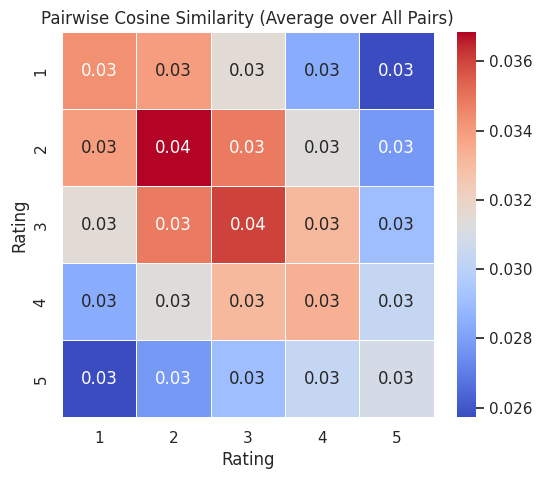

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    sim_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=ratings,
    yticklabels=ratings,
    linewidths=0.5
)

plt.title("Pairwise Cosine Similarity (Average over All Pairs)")
plt.xlabel("Rating")
plt.ylabel("Rating")

plt.show()

## Visualization

#### Visualize wordcloud for positive comments

In [ ]:
positive_cmt = data_cleaned[data_cleaned.sentiment == 1].reviewText

In [ ]:
positive_cmt = ' '.join(positive_cmt)

In [ ]:
wc = WordCloud().generate(positive_cmt)
wc

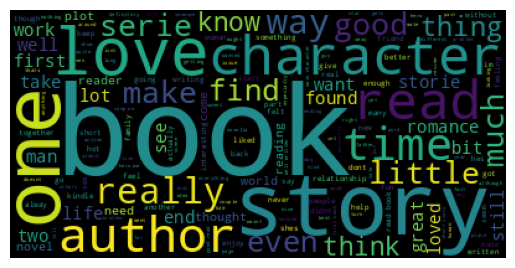

In [ ]:
plt.imshow(wc)
plt.axis('off')
plt.show()

#### Visualize wordcloud for negative comments

In [ ]:
negative_cmt = data_cleaned[data_cleaned.sentiment == 0].reviewText
negative_cmt = ' '.join(negative_cmt)
wc = WordCloud().generate(negative_cmt)
wc

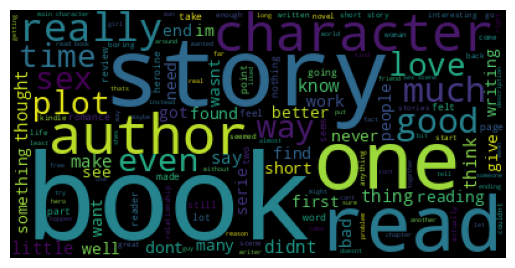

In [ ]:
plt.imshow(wc)
plt.axis('off')
plt.show()

## Build Model

#### Split into input/output

In [ ]:
X = data['reviewText']
y = data['sentiment']

In [ ]:
data.reviewText.tail(5)

11995    valentine cupid vampire jena ian another vampi...
11996    read seven book series apocalypticadventure on...
11997    book really wasnt cuppa situation man capturin...
11998    tried use charge kindle didnt even register ch...
11999    taking instruction look often hidden world sex...
Name: reviewText, dtype: object

In [ ]:
data.sentiment.head(5)

0    1
1    1
2    1
3    1
4    1
Name: sentiment, dtype: int64

#### Split into train/test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
X_train.head()

884     couldnt finish book wandered never seemed gel ...
4175    enjoyed book demon world real kept attention b...
8713    en mcnamaras grid solid mixture survival story...
4116    illustration describe good job jules verne hus...
9873    time im asked review say pretty much thing eit...
Name: reviewText, dtype: object

#### Handle imbalance dataset

##### Note: I think this is not imbalance because the negative cmt possess 30% records, imbalance in realife I think like 9:1 or 9.5 : 0.5 like card fraud detection datasets which i used to predict on kaggle

In [ ]:
y.value_counts()

sentiment
1    7994
0    3997
Name: count, dtype: int64

##### oversampling

In [ ]:
# from imblearn.over_sampling import SMOTE

##### undersampling

#### Init pipeline for transform and training

In [ ]:
#tf-idf with max_feature=900
#model logistic regression

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [ ]:
X_train.shape

(8993,)

In [ ]:
y_train.shape

(8993,)

In [ ]:
_chain = [
    ('vectorizing', TfidfVectorizer(max_features=900, stop_words='english')),
    ('modeling', LogisticRegression())
]

_pipeline = Pipeline(_chain)
_pipeline.fit(X_train, y_train)

Pipeline(steps=[('vectorizing',
                 TfidfVectorizer(max_features=900, stop_words='english')),
                ('modeling', LogisticRegression())])

In [ ]:
from sklearn.metrics import accuracy_score
y_hat_test = _pipeline.predict(X_test)
accuracy_score(y_test, y_hat_test)

0.8262174783188793

In [ ]:
y_hat_train = _pipeline.predict(X_train)
accuracy_score(y_train, y_hat_train)

0.8524407872789947

### Evaluate result

In [ ]:
# Xem kết quả thống kê
from sklearn.metrics import classification_report, confusion_matrix
confusion_matrix(y_test, y_hat_test)


array([[ 650,  349],
       [ 172, 1827]])

In [ ]:
print(classification_report(y_test, y_hat_test))

              precision    recall  f1-score   support

           0       0.79      0.65      0.71       999
           1       0.84      0.91      0.88      1999

    accuracy                           0.83      2998
   macro avg       0.82      0.78      0.79      2998
weighted avg       0.82      0.83      0.82      2998



In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

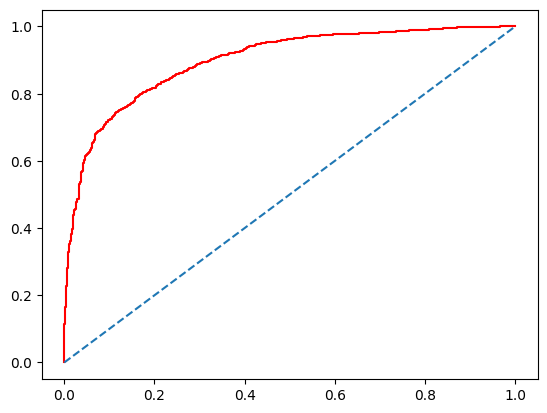

In [ ]:
# calculate roc curve
y_hat_test_proba = _pipeline.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_hat_test_proba[:,1])
plt.plot(fpr, tpr, c='r')
plt.plot([0,1], [0,1], linestyle='--')
plt.show()


In [ ]:
# calculate AUC
auc = roc_auc_score(y_test, y_hat_test_proba[:,1])
print(f'AUC: {auc}')


AUC: 0.898230396479521


### Evaluate result for adjusting threshold

In [ ]:
yhat = (y_hat_test_proba[:,1] >= 0.65).astype(int)

In [ ]:
confusion_matrix(y_test, y_hat)


array([[ 268,  731],
       [ 505, 1494]])

In [ ]:
print(classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.69      0.80      0.74       999
           1       0.89      0.82      0.85      1999

    accuracy                           0.81      2998
   macro avg       0.79      0.81      0.80      2998
weighted avg       0.82      0.81      0.82      2998



In [ ]:
# We can use loop and set some states to find the best ones

#### Save model

In [ ]:
import pickle
import os

os.makedirs('model_checkpoints', exist_ok=True)
pickle.dump(_pipeline, open('model_checkpoints/model.pkl', 'wb'))